# Praktikum 1 - Minggu 4: EDA Univariat dan Deteksi Outlier

Mata Kuliah: Data Analitik
CPMK-3 / Sub-CPMK-04

Prasyarat: jalankan Praktikum 2 Minggu 3 terlebih dahulu sehingga file
`data_raw/cuaca_bersih.csv` dan `data_raw/buku_bersih.csv` tersedia.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df_cuaca = pd.read_csv("cuaca_bersih.csv")
df_buku = pd.read_csv("buku_bersih.csv")
df_cuaca["waktu"] = pd.to_datetime(df_cuaca["waktu"])  # kolom tanggal perlu diparse ulang setelah dibaca dari CSV

print("Cuaca:", df_cuaca.shape, "| Buku:", df_buku.shape)

Cuaca: (216, 9) | Buku: (100, 5)


## Bagian A — Statistik Deskriptif Univariat

In [2]:
def statistik_univariat(s, nama):
    print(f"\n=== {nama} ===")
    print(f"Mean     : {s.mean():.2f}")
    print(f"Median   : {s.median():.2f}")
    print(f"Modus    : {s.mode().iloc[0]:.2f}")
    print(f"Range    : {s.max() - s.min():.2f}")
    print(f"Variance : {s.var():.2f}")
    print(f"Std Dev  : {s.std():.2f}")
    print(f"IQR      : {s.quantile(0.75) - s.quantile(0.25):.2f}")


statistik_univariat(df_cuaca["suhu_c"], "Suhu (C)")
statistik_univariat(df_buku["harga_numeric"], "Harga Buku")

df_cuaca[["suhu_c", "kelembapan_persen", "presipitasi_mm"]].describe()



=== Suhu (C) ===
Mean     : 24.90
Median   : 24.70
Modus    : 21.60
Range    : 14.00
Variance : 13.16
Std Dev  : 3.63
IQR      : 5.50

=== Harga Buku ===
Mean     : 34.64
Median   : 34.14
Modus    : 59.59
Range    : 49.53
Variance : 226.73
Std Dev  : 15.06
IQR      : 26.97


,suhu_c,kelembapan_persen,presipitasi_mm
count,216.000000,216.000000,216.000000
mean,24.898148,77.822222,0.399537
std,3.628030,8.610641,1.577443
min,18.700000,58.000000,0.000000
25%,21.925000,71.300000,0.000000
50%,24.700000,77.600000,0.000000
75%,27.425000,84.800000,0.000000
max,32.700000,95.400000,13.600000


## Bagian B — Analisis Bentuk Distribusi

In [3]:
def analisis_distribusi(s, nama):
    sk = stats.skew(s.dropna())
    kt = stats.kurtosis(s.dropna())
    print(f"\n{nama}: skewness={sk:.3f}, kurtosis={kt:.3f}")
    if abs(sk) < 0.5:
        bentuk = "relatif simetris"
    elif sk > 0:
        bentuk = "condong kanan (positive skew)"
    else:
        bentuk = "condong kiri (negative skew)"
    print(f"  -> Bentuk distribusi: {bentuk}")
    return sk, kt


sk_suhu, kt_suhu = analisis_distribusi(df_cuaca["suhu_c"], "Suhu (C)")
sk_harga, kt_harga = analisis_distribusi(df_buku["harga_numeric"], "Harga Buku")



Suhu (C): skewness=0.331, kurtosis=-0.660
  -> Bentuk distribusi: relatif simetris

Harga Buku: skewness=0.025, kurtosis=-1.300
  -> Bentuk distribusi: relatif simetris


## Bagian C — Deteksi Outlier

In [4]:
def outlier_zscore(s, ambang=3):
    z = (s - s.mean()) / s.std()
    return z.abs() > ambang


def outlier_iqr(s, faktor=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - faktor * iqr) | (s > q3 + faktor * iqr)


mask_z_suhu = outlier_zscore(df_cuaca["suhu_c"])
mask_iqr_suhu = outlier_iqr(df_cuaca["suhu_c"])

print("Outlier suhu (Z-score):", mask_z_suhu.sum())
print("Outlier suhu (IQR)    :", mask_iqr_suhu.sum())
print(df_cuaca.loc[mask_iqr_suhu, ["kota", "waktu", "suhu_c"]])

mask_z_harga = outlier_zscore(df_buku["harga_numeric"])
mask_iqr_harga = outlier_iqr(df_buku["harga_numeric"])

print("\nOutlier harga (Z-score):", mask_z_harga.sum())
print("Outlier harga (IQR)    :", mask_iqr_harga.sum())
print(df_buku.loc[mask_iqr_harga, ["judul", "harga_numeric"]])


Outlier suhu (Z-score): 0
Outlier suhu (IQR)    : 0
Empty DataFrame
Columns: [kota, waktu, suhu_c]
Index: []

Outlier harga (Z-score): 0
Outlier harga (IQR)    : 0
Empty DataFrame
Columns: [judul, harga_numeric]
Index: []


## Bagian D — Visualisasi Univariat

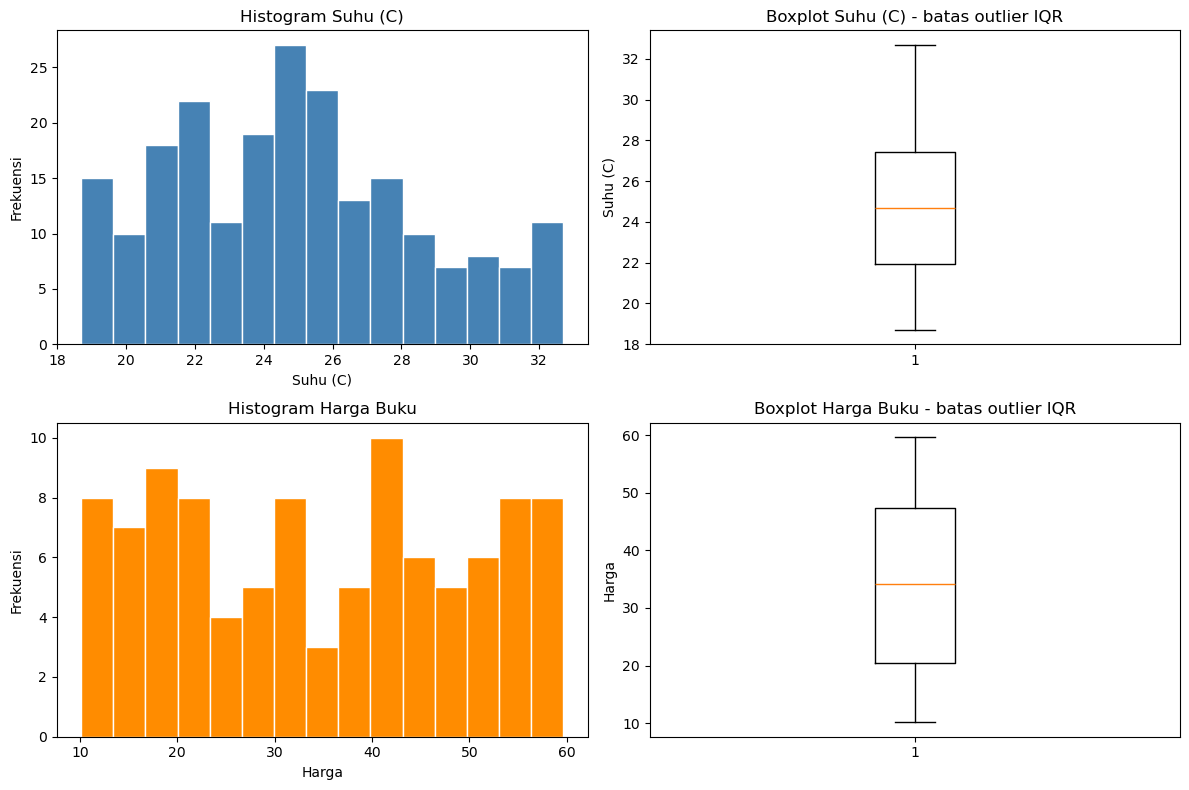

Visualisasi tersimpan: data_raw/viz_eda_univariat.png


In [5]:
import os
os.makedirs("data_raw", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df_cuaca["suhu_c"], bins=15, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Histogram Suhu (C)")
axes[0, 0].set_xlabel("Suhu (C)")
axes[0, 0].set_ylabel("Frekuensi")

axes[0, 1].boxplot(df_cuaca["suhu_c"], vert=True)
axes[0, 1].set_title("Boxplot Suhu (C) - batas outlier IQR")
axes[0, 1].set_ylabel("Suhu (C)")

axes[1, 0].hist(df_buku["harga_numeric"], bins=15, color="darkorange", edgecolor="white")
axes[1, 0].set_title("Histogram Harga Buku")
axes[1, 0].set_xlabel("Harga")
axes[1, 0].set_ylabel("Frekuensi")

axes[1, 1].boxplot(df_buku["harga_numeric"], vert=True)
axes[1, 1].set_title("Boxplot Harga Buku - batas outlier IQR")
axes[1, 1].set_ylabel("Harga")

plt.tight_layout()
plt.savefig("data_raw/viz_eda_univariat.png", dpi=150)
plt.show()

print("Visualisasi tersimpan: data_raw/viz_eda_univariat.png")


In [6]:
df_cuaca["outlier_suhu_iqr"] = mask_iqr_suhu
df_buku["outlier_harga_iqr"] = mask_iqr_harga

df_cuaca.to_csv("data_raw/cuaca_eda_univariat.csv", index=False)
df_buku.to_csv("data_raw/buku_eda_univariat.csv", index=False)
print("Hasil EDA univariat tersimpan untuk dipakai pada Praktikum 2.")

Hasil EDA univariat tersimpan untuk dipakai pada Praktikum 2.


## Bagian E — Studi Kasus: Outlier pada Dataset UMKM Toba

Dataset `data_raw/penjualan_toba_bersih.csv` (hasil Praktikum 2 Minggu 3) berisi 4 kategori produk
dengan skala harga yang sangat berbeda. Ini membuat deteksi outlier global menyesatkan: outlier di
kategori Camilan bisa "tenggelam" di antara harga Kerajinan yang memang wajar tinggi.


In [8]:
df_umkm = pd.read_csv("data_raw/penjualan_toba_bersih.csv")

# Deteksi outlier GLOBAL (naif, skala tercampur)
mask_global = outlier_iqr(df_umkm["harga_satuan"])
print("Outlier global (IQR):", mask_global.sum(), "dari", len(df_umkm))

# Deteksi outlier PER KATEGORI (benar, karena skala harga dipisah per kelompok)
df_umkm["outlier_harga_percategory"] = df_umkm.groupby("kategori")["harga_satuan"].transform(lambda s: outlier_iqr(s))
print("Outlier per kategori (IQR):", df_umkm["outlier_harga_percategory"].sum())
print(df_umkm.loc[df_umkm["outlier_harga_percategory"], ["produk", "kategori", "harga_satuan"]])

# Simpan kembali agar kolom outlier tersedia untuk Praktikum 2 Minggu 4
df_umkm.to_csv("data_raw/penjualan_toba_bersih.csv", index=False)

Outlier global (IQR): 0 dari 2764
Outlier per kategori (IQR): 0
Empty DataFrame
Columns: [produk, kategori, harga_satuan]
Index: []


Deteksi per kategori menemukan lebih banyak outlier yang valid dibanding deteksi global,
karena setiap kategori dinilai dengan skalanya sendiri. Periksa baris yang ditandai outlier: apakah
harga tersebut tampak seperti kesalahan input (misalnya persis 100x lipat dari harga wajar produk
yang sama), atau variasi wajar?

## Tugas Praktikum 1 Minggu 4 (versi UMKM Toba)

Gunakan dataset UMKM Toba (`data_raw/penjualan_toba_bersih.csv`). Pilih satu kategori produk dan
fokuskan analisis pada `harga_satuan` dalam kategori tersebut saja: statistik univariat lengkap,
skewness/kurtosis, deteksi outlier (Z-score dan IQR, dibandingkan dengan hasil global), histogram
dan boxplot, serta kesimpulan singkat. Lihat modul lengkap untuk instruksi dan rubrik penilaian.
